In [15]:
import pandas as pd

In [16]:
dados = pd.read_csv('vendas.CSV')

In [17]:
dados.head()

,Data,Produto,Categoria,Quantidade,Preco_Unitario,Vendedor,Cidade
0,2026-01-05,Notebook,Informática,2,3500,Ana,Recife
1,2026-01-06,Mouse,Informática,10,80,Carlos,Olinda
2,2026-01-07,Teclado,Informática,5,150,Ana,Recife
3,2026-01-08,Monitor,Informática,3,1200,Marcos,Jaboatão
4,2026-01-09,Cadeira Gamer,Móveis,2,950,Carlos,Recife


In [18]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Data            26 non-null     str  
 1   Produto         26 non-null     str  
 2   Categoria       26 non-null     str  
 3   Quantidade      26 non-null     int64
 4   Preco_Unitario  26 non-null     int64
 5   Vendedor        26 non-null     str  
 6   Cidade          26 non-null     str  
dtypes: int64(2), str(5)
memory usage: 1.6 KB


In [19]:
dados.describe()

,Quantidade,Preco_Unitario
count,26.000000,26.000000
mean,4.500000,1118.076923
std,3.591657,1253.724114
min,1.000000,80.000000
25%,2.000000,175.000000
50%,3.000000,900.000000
75%,6.000000,1200.000000
max,15.000000,3500.000000


In [20]:
dados['Faturamento'] = dados['Quantidade'] * dados['Preco_Unitario']

print(dados)

          Data         Produto    Categoria  Quantidade  Preco_Unitario  \
0   2026-01-05        Notebook  Informática           2            3500   
1   2026-01-06           Mouse  Informática          10              80   
2   2026-01-07         Teclado  Informática           5             150   
3   2026-01-08         Monitor  Informática           3            1200   
4   2026-01-09   Cadeira Gamer       Móveis           2             950   
5   2026-01-10  Fone Bluetooth  Eletrônicos           8             250   
6   2026-01-11        Notebook  Informática           1            3500   
7   2026-01-12           Mouse  Informática           7              80   
8   2026-01-13         Teclado  Informática           4             150   
9   2026-01-14         Monitor  Informática           2            1200   
10  2026-01-15          Webcam  Eletrônicos           6             300   
11  2026-01-16      Impressora  Informática           2             900   
12  2026-01-17        Not

In [21]:
dados['Faturamento'].sum()

np.int64(66570)

In [22]:
dados.groupby('Produto')['Quantidade'].sum()

Produto
Cadeira Gamer      6
Fone Bluetooth    20
Impressora         3
Monitor           11
Mouse             44
Notebook           9
Teclado           15
Webcam             9
Name: Quantidade, dtype: int64

In [23]:
dados.groupby('Produto')['Faturamento'].sum()

Produto
Cadeira Gamer      5700
Fone Bluetooth     5000
Impressora         2700
Monitor           13200
Mouse              3520
Notebook          31500
Teclado            2250
Webcam             2700
Name: Faturamento, dtype: int64

In [24]:
import matplotlib.pyplot as plt

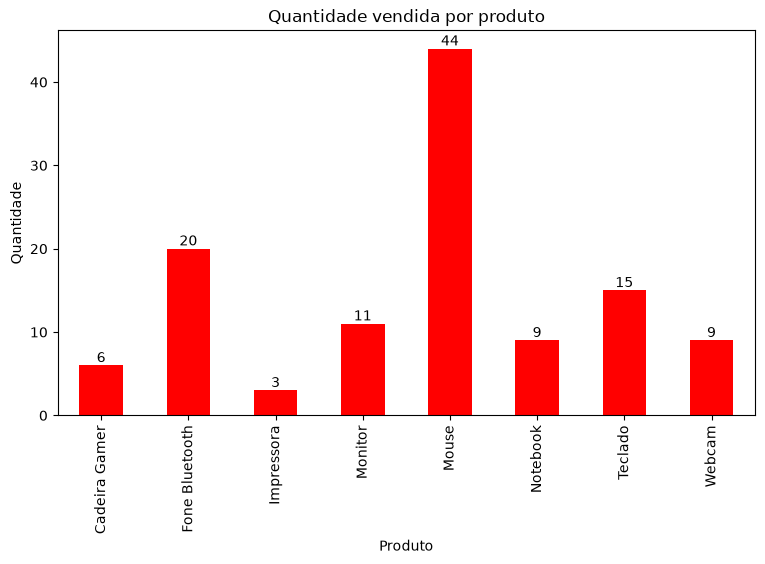

In [32]:
import matplotlib.pyplot as plt

vendas = dados.groupby('Produto')['Quantidade'].sum()

vendas.plot(kind='bar', color='red', figsize=(9, 5))

ax = vendas.plot(kind="bar", color="red")
ax.bar_label(ax.containers[0])

plt.title("Quantidade vendida por produto")
plt.xlabel("Produto")
plt.ylabel("Quantidade")

plt.show()

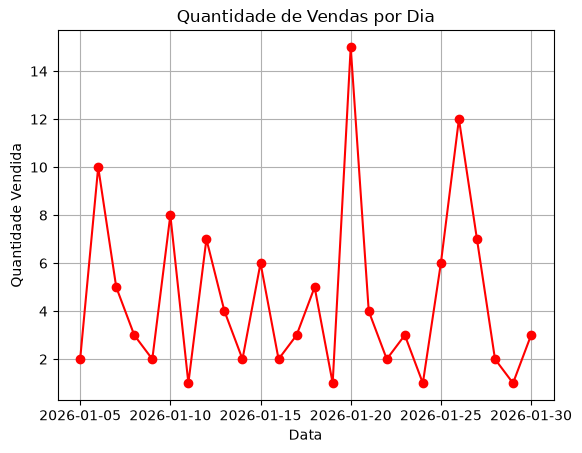

In [47]:


vendas_dia = dados.groupby("Data")["Quantidade"].sum()


ax = vendas_dia.plot(kind="line", marker="o", color="red")


plt.title("Quantidade de Vendas por Dia")
plt.xlabel("Data")
plt.ylabel("Quantidade Vendida")
plt.grid(True)

plt.show()

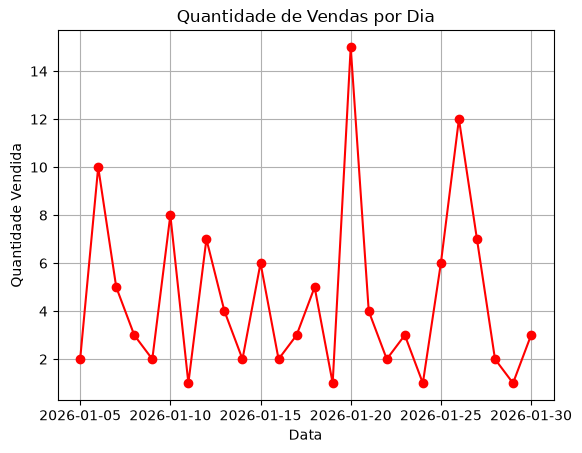

In [49]:



vendas_dia = dados.groupby("Data")["Quantidade"].sum()

ax = vendas_dia.plot(kind="line", marker="o", color="red")

plt.title("Quantidade de Vendas por Dia")
plt.xlabel("Data")
plt.ylabel("Quantidade Vendida")
plt.grid(True)

plt.show()

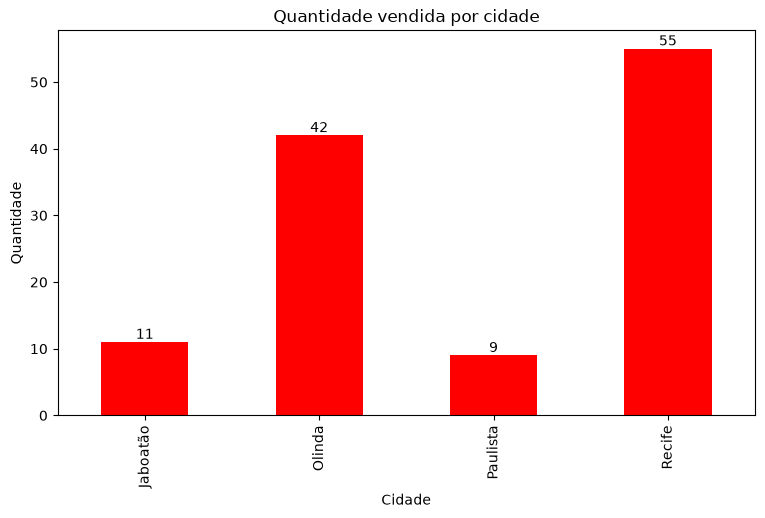

In [52]:
vendas = dados.groupby('Cidade')['Quantidade'].sum()

vendas.plot(kind='bar', color='red', figsize=(9, 5))

ax = vendas.plot(kind="bar", color="red")
ax.bar_label(ax.containers[0])

plt.title("Quantidade vendida por cidade")
plt.xlabel("Cidade")
plt.ylabel("Quantidade")

plt.show()

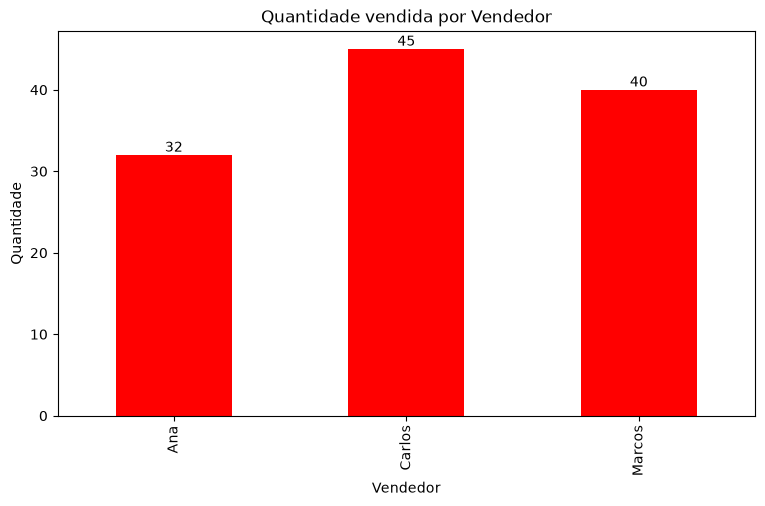

In [54]:
vendas = dados.groupby('Vendedor')['Quantidade'].sum()

vendas.plot(kind='bar', color='red', figsize=(9, 5))

ax = vendas.plot(kind="bar", color="red")
ax.bar_label(ax.containers[0])

plt.title("Quantidade vendida por Vendedor")
plt.xlabel("Vendedor")
plt.ylabel("Quantidade")

plt.show()

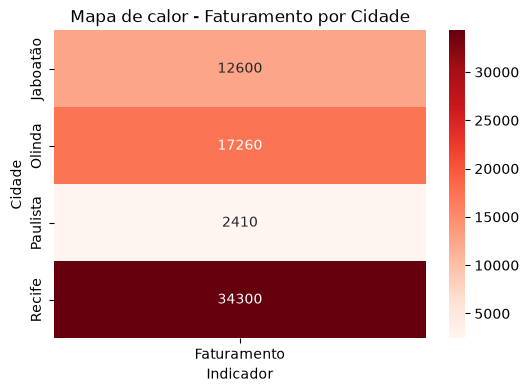

In [56]:
import seaborn as sns




faturamento_cidade = (
    dados.groupby("Cidade")["Faturamento"]
    .sum()
)




heatmap_dados = faturamento_cidade.to_frame()


plt.figure(figsize=(6,4))

sns.heatmap(
    heatmap_dados,
    annot=True,       # mostra os valores
    fmt=".0f",        # formato número inteiro
    cmap="Reds"
)


plt.title("Mapa de calor - Faturamento por Cidade")

plt.xlabel("Indicador")

plt.ylabel("Cidade")

plt.show()

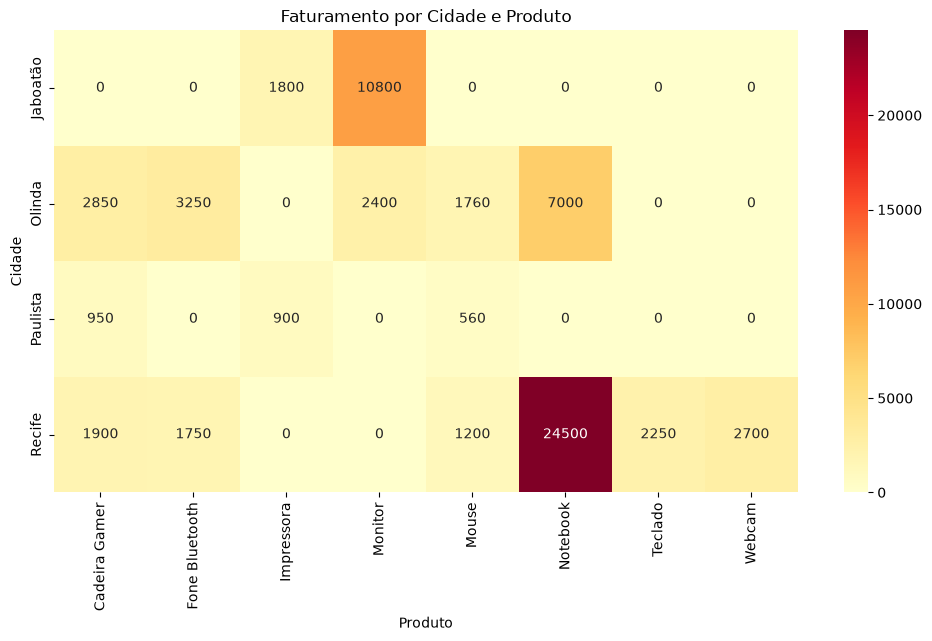

In [58]:
tabela = pd.pivot_table(
    dados,
    values="Faturamento",
    index="Cidade",
    columns="Produto",
    aggfunc="sum",
    fill_value=0
)


plt.figure(figsize=(12,6))

sns.heatmap(
    tabela,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)


plt.title("Faturamento por Cidade e Produto")

plt.show()

In [63]:


produto_cidade = (
    dados.groupby(["Cidade", "Produto"])["Quantidade"]
    .sum()
    .reset_index()
)


print(produto_cidade)

      Cidade         Produto  Quantidade
0   Jaboatão      Impressora           2
1   Jaboatão         Monitor           9
2     Olinda   Cadeira Gamer           3
3     Olinda  Fone Bluetooth          13
4     Olinda         Monitor           2
5     Olinda           Mouse          22
6     Olinda        Notebook           2
7   Paulista   Cadeira Gamer           1
8   Paulista      Impressora           1
9   Paulista           Mouse           7
10    Recife   Cadeira Gamer           2
11    Recife  Fone Bluetooth           7
12    Recife           Mouse          15
13    Recife        Notebook           7
14    Recife         Teclado          15
15    Recife          Webcam           9


In [65]:
produto_top_cidade = (
    produto_cidade
    .sort_values(
        "Quantidade",
        ascending=False
    )
    .groupby("Cidade")
    .first()
)


print(produto_top_cidade)


          Produto  Quantidade
Cidade                       
Jaboatão  Monitor           9
Olinda      Mouse          22
Paulista    Mouse           7
Recife    Teclado          15


In [70]:
faturamento_cidade_produto = (
    dados.groupby(
        ["Cidade", "Produto"]
    )["Faturamento"]
    .sum()
    .reset_index()
)


print(faturamento_cidade_produto)

      Cidade         Produto  Faturamento
0   Jaboatão      Impressora         1800
1   Jaboatão         Monitor        10800
2     Olinda   Cadeira Gamer         2850
3     Olinda  Fone Bluetooth         3250
4     Olinda         Monitor         2400
5     Olinda           Mouse         1760
6     Olinda        Notebook         7000
7   Paulista   Cadeira Gamer          950
8   Paulista      Impressora          900
9   Paulista           Mouse          560
10    Recife   Cadeira Gamer         1900
11    Recife  Fone Bluetooth         1750
12    Recife           Mouse         1200
13    Recife        Notebook        24500
14    Recife         Teclado         2250
15    Recife          Webcam         2700
